**Author:** Salvador Navas  
**Reference model:** Muncie, Indiana — 2D unsteady flow (official HEC-RAS tutorial)  
**Source:** [HEC-RAS 2D User Manual Examples](https://www.hec.usace.army.mil/confluence/rasdocs/r2dum)

### HEC-RAS — Automated hydraulic modelling with `pyhydra`

The Muncie example is the standard 2D tutorial that ships with HEC-RAS.  
White River through downtown Muncie, IN; 2D unsteady; combined culverts + bridges;  
inflow from HEC-HMS (upstream BC) + lateral inflows.

Workflow:
1. Project configuration
2. Return-period hydrographs as boundary conditions
3. Modify unsteady flow file (.u##)
4. Modify plan (.p##) and project (.prj) files
5. Run HEC-RAS when the binary/project are available
6. Extract WSEL results, or label the Manning fallback approximation
7. Climate-change delta-factor runs


In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
from pathlib import Path

from pyhydra.modeling.hydraulic.hec_ras import (
    modify_unsteady_file, modify_plan_file, modify_project_file,
    create_flow_series, run_hec_ras,
    read_ras_dss_timeseries, read_ras_max_wsel,
)


---
## 1. 📂 Project configuration

Download the Muncie 2D example from HEC-RAS documentation:  
`Help → Example Data Sets → 2D Unsteady → Muncie_2D`  
or from: https://www.hec.usace.army.mil/confluence/rasdocs/r2dum  

Place the project folder at the path below.


In [ ]:
# === USER CONFIGURATION — Muncie, Indiana ===
NAME_PROJECT    = 'Muncie'          # .prj file stem
VERSION_HEC_RAS = 641               # HEC-RAS version (e.g. 641 = 6.4.1)

PLAN_NUMBER   = 1                   # current plan = .p01
FLOW_FILE_NUM = 5                   # base unsteady file = .u05

RETURN_PERIODS = [2, 5, 10, 25, 50, 100, 500]

BC_PATHNAMES = [
    '/BCLINE/Perimeter 1: Upstream/FLOW/Sep2008/10Minute/plan:base/',
    '/BCLINE/Perimeter 1: Lateral 1/FLOW/Sep2008/10Minute/plan:base/',
]

# HEC-RAS requires a numeric 1-99 suffix for .u##/.p## files — PLAN_IDS maps
# each return period to that file number (PLAN_NUMBER=1 is the base plan).
# 'T{T}yr' labels below are for print/plot only, never used as a filename.
PLAN_IDS = {T: i + 2 for i, T in enumerate(RETURN_PERIODS)}

# Path resolution (Docker → local notebook dir → HYDRA repo root)
RUNTIME_ROOT = Path(os.environ.get('HYDRA_RUNTIME_DIR', Path.cwd() / '.hydra_runtime'))
WORK_PROJECT = RUNTIME_ROOT / 'hec_ras' / 'Muncie'

_candidates = [
    Path('/workspace/data/hec_ras/Muncie'),
    Path.cwd() / 'data' / 'hec_ras' / 'Muncie',
    Path.cwd().parents[2] / 'data' / 'hec_ras' / 'Muncie',  # HYDRA repo root
]
SOURCE_PROJECT = next((p for p in _candidates if p.exists()), _candidates[1])

if SOURCE_PROJECT.exists() and not WORK_PROJECT.exists():
    WORK_PROJECT.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(SOURCE_PROJECT, WORK_PROJECT)

PATH_PROJECT = str(WORK_PROJECT if WORK_PROJECT.exists() else SOURCE_PROJECT) + '/'

# Hydrograph CSVs: prefer HMS runtime copy, then pre-computed data
_hms_runtime = RUNTIME_ROOT / 'hms' / 'Tifton' / 'Outputs'
_hms_source  = Path('/workspace/data/hms/Tifton/Outputs')
HMS_OUTPUT_DIR = str(_hms_runtime if _hms_runtime.exists() else _hms_source) + '/'

print(f'Project  : {NAME_PROJECT}')
print(f'Source   : {SOURCE_PROJECT}  ({"found" if SOURCE_PROJECT.exists() else "not found"})')
print(f'Workdir  : {PATH_PROJECT}')
print(f'HMS out  : {HMS_OUTPUT_DIR}')
print(f'Returns  : {RETURN_PERIODS}')

---
## 2. 🌊 Return-period hydrographs (from HEC-HMS)

Load the HEC-HMS peak-flow hydrographs computed in the previous notebook
and smooth them for hydraulic stability.


7 hydrographs loaded  |  Qp T100 = 250.6 m3/s
Hydrograph sources:
  7 x illustrative synthetic fallback (HMS output missing)


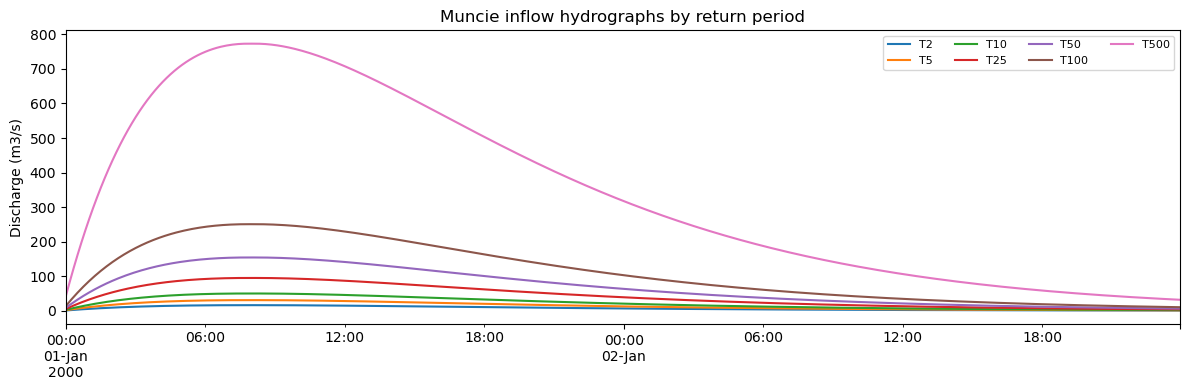

In [3]:
# Load HEC-HMS output CSVs (one per return period, produced in HEC_HMS.ipynb)
hydrographs = {}
hydrograph_sources = {}
for T in RETURN_PERIODS:
    fp = HMS_OUTPUT_DIR + f'Q_T{T}.csv'
    if os.path.exists(fp):
        df = pd.read_csv(fp, index_col=0, parse_dates=True)
        col_map = {c: 'flow' for c in ('Q_CMS', 'Q_m3s', 'Q') if c in df.columns}
        if not col_map and 'Q_CFS' in df.columns:
            df['flow'] = df['Q_CFS'] / 35.3147
        else:
            df = df.rename(columns=col_map)
        hydrograph_sources[T] = f'HMS output: {fp}'
    else:
        t   = np.linspace(0, 48, 576)
        Qp  = 50 * (T / 10) ** 0.7
        q   = Qp * (t / 8) * np.exp(1 - t / 8)
        idx = pd.date_range('2000-01-01', periods=576, freq='5min')
        df  = pd.DataFrame({'flow': np.maximum(q, 0.0)}, index=idx)
        hydrograph_sources[T] = 'illustrative synthetic fallback (HMS output missing)'
    df['flow_smooth'] = create_flow_series(df, col='flow', window=5)
    hydrographs[T] = df

source_counts = pd.Series(hydrograph_sources).value_counts()
print(f'{len(hydrographs)} hydrographs loaded  |  Qp T100 = {hydrographs[100]["flow_smooth"].max():.1f} m3/s')
print('Hydrograph sources:')
for source, count in source_counts.items():
    print(f'  {count} x {source}')

fig, ax = plt.subplots(figsize=(12, 4))
for T in RETURN_PERIODS:
    hydrographs[T]['flow_smooth'].plot(ax=ax, label=f'T{T}')
ax.set(ylabel='Discharge (m3/s)', title='Muncie inflow hydrographs by return period')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


---
## 3. 🔧 Modify HEC-RAS input files

For each return period:
1. Copy and update the unsteady flow file (`.u##`) with the new hydrograph
2. Update the plan file (`.p##`) to reference the new unsteady file
3. Update the project file (`.prj`) to set the current plan


In [ ]:
HAS_MUNCIE = (
    os.path.exists(PATH_PROJECT + NAME_PROJECT + '.prj') and
    os.path.exists(PATH_PROJECT + NAME_PROJECT + f'.u{FLOW_FILE_NUM:02d}')
)

if HAS_MUNCIE:
    for T in RETURN_PERIODS:
        plan_id   = PLAN_IDS[T]
        plan_name = f'T{T}yr'  # label only — file suffix is plan_id
        q_series  = hydrographs[T][['flow_smooth']].rename(columns={'flow_smooth': 'flow'})

        modify_unsteady_file(
            path_project       = PATH_PROJECT,
            name_project       = NAME_PROJECT,
            file_number        = FLOW_FILE_NUM,
            rainfall_plan_name = plan_id,
            flow_series        = q_series,
            bc_pathnames       = BC_PATHNAMES,
        )
        modify_plan_file(
            path_project       = PATH_PROJECT,
            name_project       = NAME_PROJECT,
            plan_number        = PLAN_NUMBER,
            rainfall_plan_name = plan_id,
        )
        modify_project_file(
            path_project       = PATH_PROJECT,
            name_project       = NAME_PROJECT,
            plan_number        = PLAN_NUMBER,
            rainfall_plan_name = plan_id,
        )
        print(f'T{T:3d} ({plan_name}, plan p{plan_id:02d}) — files updated')
else:
    _data_dir = Path.cwd().parents[2] / 'data' / 'hec_ras' / 'Muncie'
    print('Muncie project files not found. To enable HEC-RAS file modification:')
    print('  1. Open HEC-RAS → Help → Example Data Sets → 2D Unsteady → Muncie_2D')
    print(f'  2. Place the project folder at:')
    print(f'       {_data_dir}')
    print(f'     or: {Path.cwd() / "data" / "hec_ras" / "Muncie"}')
    print('(File modification skipped — synthetic hydrographs already shown above)')

---
## 4. ▶️ Run HEC-RAS


In [ ]:
WSEL_results = {}
WSEL_METHOD = 'HEC-RAS DSS output'

from scipy.optimize import brentq

CH_B  = 65.0      # channel bottom width (m)
CH_Z  = 2.0       # side slope (horizontal : vertical)
CH_N  = 0.032     # Manning roughness (natural channel, mild vegetation)
CH_S  = 6.5e-4    # longitudinal bed slope (m/m)
Z_BED = 280.0     # channel bottom elevation (m NAVD88)


def _normal_depth(Q):
    def _err(y):
        A = (CH_B + CH_Z * y) * y
        P = CH_B + 2 * y * np.sqrt(1 + CH_Z ** 2)
        R = A / P
        return (A / CH_N) * R ** (2 / 3) * CH_S ** 0.5 - Q
    return brentq(_err, 0.01, 30.0)


def _fill_manning_wsel(reason):
    global WSEL_METHOD
    WSEL_METHOD = f'Manning 1D normal-depth fallback (approximate; not HEC-RAS output) - {reason}'
    for T in RETURN_PERIODS:
        Q_peak = hydrographs[T]['flow_smooth'].max()
        yn = _normal_depth(Q_peak)
        WSEL_results[T] = Z_BED + yn
    print(f'HEC-RAS WSEL unavailable: {reason}')
    print('Using Manning 1D normal-depth fallback:')
    print('  White River cross-section: B=65 m, z=2:1, n=0.032, S=6.5e-4')
    print(f'  {"T":>5}  {"Q_peak (m3/s)":>14}  {"yn (m)":>8}  {"WSEL (m)":>10}')
    for T in RETURN_PERIODS:
        Q_p = hydrographs[T]['flow_smooth'].max()
        yn  = WSEL_results[T] - Z_BED
        print(f'  {T:>5}  {Q_p:>14.1f}  {yn:>8.2f}  {WSEL_results[T]:>10.2f}')


# Override if the geometry's river/reach or 2D perimeter name differs
# (check 'WSEL' results in RAS Mapper for the exact DSS B-part).
WSEL_PATHNAME_PREFIX = os.getenv('HYDRA_RAS_WSEL_PATHNAME', '//White River - Muncie/WSEL')

if HAS_MUNCIE:
    try:
        dss_path = Path(PATH_PROJECT, NAME_PROJECT + '.dss')
        for T in RETURN_PERIODS:
            plan_id = PLAN_IDS[T]
            modify_project_file(PATH_PROJECT, NAME_PROJECT, PLAN_NUMBER, plan_id)
            ret = run_hec_ras(PATH_PROJECT, NAME_PROJECT, ras_version=VERSION_HEC_RAS)
            print(f'T{T}: return code = {ret}')
            # DSS extraction (hecdss; assumes HEC-RAS's default Plan Short
            # ID 'p<NN>' as the F-part PLAN: tag — verify in the Plan Editor
            # if a plan's Short ID was customised).
            WSEL_results[T] = read_ras_max_wsel(
                str(dss_path), WSEL_PATHNAME_PREFIX, plan_name=f'p{plan_id:02d}',
            )
    except Exception as exc:
        _fill_manning_wsel(f'{type(exc).__name__}: {exc}')

    if not WSEL_results:
        _fill_manning_wsel('HEC-RAS DSS WSEL extraction was not configured')
else:
    _fill_manning_wsel('Muncie project files were not found')


---
## 5. 📊 WSEL frequency curve and flood mapping


WSEL method: Manning 1D normal-depth fallback (approximate; not HEC-RAS output) - Muncie project files were not found
2      280.497201
5      280.729933
10     280.975642
25     281.430818
50     281.910133
100    282.547600
500    284.940709


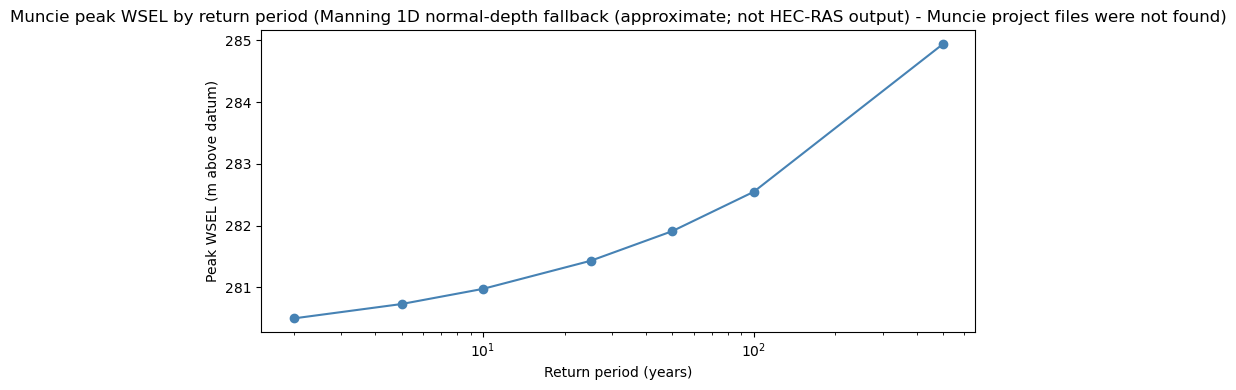

In [6]:
df_wsel = pd.Series(WSEL_results, name='Max WSEL (m)')
print(f'WSEL method: {WSEL_METHOD}')
print(df_wsel.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(df_wsel.index, df_wsel.values, 'o-', color='steelblue')
ax.set(xlabel='Return period (years)',
       ylabel='Peak WSEL (m above datum)',
       title=f'Muncie peak WSEL by return period ({WSEL_METHOD})')
plt.tight_layout()


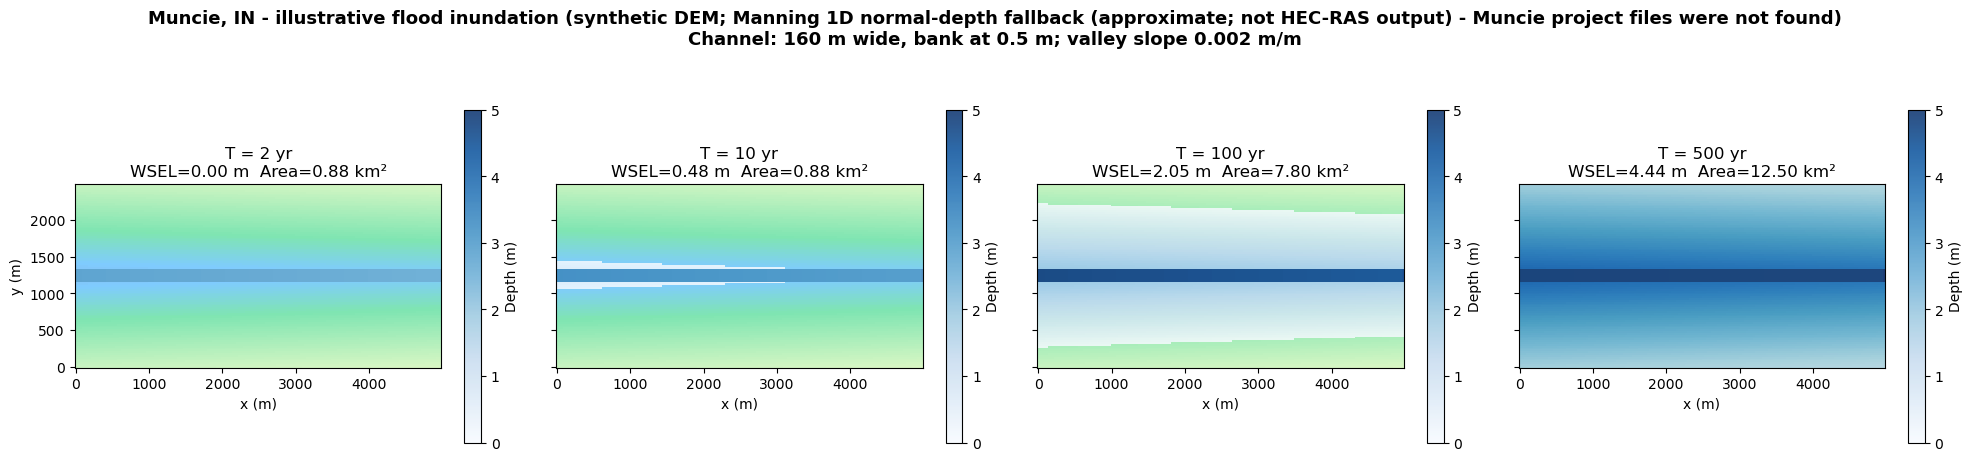

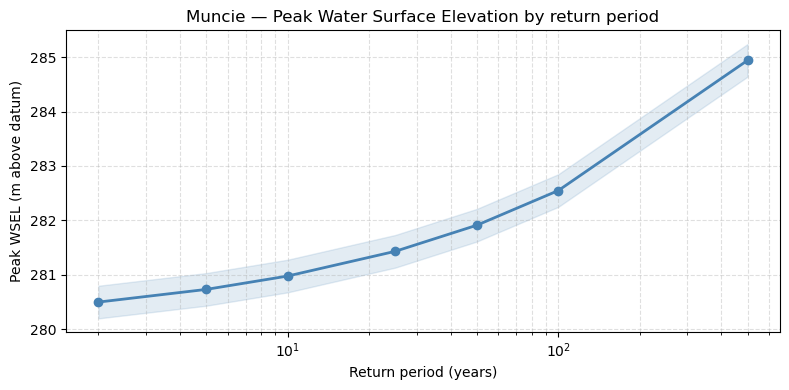

In [7]:
# Illustrative inundation map - Muncie, Indiana (synthetic geometry)
# Geometry: White River valley running E-W through Muncie
# Channel: ~80 m wide, 3 m deep; floodplain: 1500 m each side
# WSEL from WSEL_results dict (log-linear from T2 to T500)

import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch

# Build a 200×100 cell synthetic DEM (Δx=Δy=25 m → 5km×2.5km domain)
nx_ras, ny_ras = 200, 100
dx_ras = 25.0   # m
x_ras  = np.arange(nx_ras) * dx_ras
y_ras  = np.arange(ny_ras) * dx_ras
XX_ras, YY_ras = np.meshgrid(x_ras, y_ras)

# Channel centre at y=1250 m; low banks so T5-T100 produce visible flooding
cy_ras  = (ny_ras * dx_ras) / 2.0
ch_half = 80.0    # half-width (m) — 160 m wide channel
# Bank elevation = 0.5 m; valley slope 0.002 m/m from bank edge outward
val_elev = 0.5 + 0.002 * np.maximum(0.0, np.abs(YY_ras - cy_ras) - ch_half)
ch_mask  = np.abs(YY_ras - cy_ras) < ch_half
# Channel 3 m below bank (bottom at -2.5 m); flat-bottom cross-section
DEM_ras = np.where(ch_mask, -2.5, val_elev)

# Longitudinal slope: 0.3 m over 5 km (gentle floodplain)
DEM_ras -= (x_ras.max() - XX_ras) * 0.00006

# ── Flood depth for each return period ───────────────────────────────────────
WSEL_local = {T: WSEL_results[T] - WSEL_results[2] for T in RETURN_PERIODS}

selected = [2, 10, 100, 500]  # T2 near-channel, T100 wide, T500 full
colors_T  = {'T2': '#1a9850', 'T10': '#91cf60', 'T100': '#fc8d59', 'T500': '#d73027'}

fig, axes = plt.subplots(1, len(selected), figsize=(20, 5), sharey=True)

for ax, T in zip(axes, selected):
    wsel = WSEL_local[T]
    depth_ras = np.maximum(0.0, wsel - DEM_ras)
    # mask channel cells that are below datum but unflooded
    depth_ras = np.where(DEM_ras > -3.0, depth_ras, np.maximum(0.0, wsel - DEM_ras))

    # DEM backdrop
    ax.pcolormesh(x_ras, y_ras, np.ma.array(DEM_ras, mask=DEM_ras < -2.5),
                  cmap='terrain', vmin=-1, vmax=8, shading='nearest', alpha=0.5)
    ax.pcolormesh(x_ras, y_ras,
                  np.ma.array(DEM_ras, mask=DEM_ras >= -2.5),
                  cmap='Blues_r', vmin=-5, vmax=0, shading='nearest', alpha=0.7)

    # Flood depth
    flood_d = np.ma.array(depth_ras, mask=depth_ras < 0.05)
    im = ax.pcolormesh(x_ras, y_ras, flood_d,
                        cmap='Blues', vmin=0, vmax=5, shading='nearest', alpha=0.85)
    plt.colorbar(im, ax=ax, label='Depth (m)', shrink=0.8)

    n_flood = int((depth_ras > 0.3).sum())
    area    = n_flood * dx_ras**2 / 1e6
    ax.set_title(f'T = {T} yr\nWSEL={wsel:.2f} m  Area={area:.2f} km²')
    ax.set_xlabel('x (m)')
    if ax is axes[0]:
        ax.set_ylabel('y (m)')
    ax.set_aspect('equal')

fig.suptitle(f'Muncie, IN - illustrative flood inundation (synthetic DEM; {WSEL_METHOD})\nChannel: 160 m wide, bank at 0.5 m; valley slope 0.002 m/m',
             fontsize=13, fontweight='bold')
plt.tight_layout()

# ── WSEL vs T curve (summary) ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 4))
T_arr  = np.array(sorted(WSEL_results.keys()))
ws_arr = np.array([WSEL_results[t] for t in T_arr])
ax2.semilogx(T_arr, ws_arr, 'o-', color='steelblue', lw=2)
ax2.fill_between(T_arr, ws_arr - 0.3, ws_arr + 0.3, alpha=0.15, color='steelblue')
ax2.set(xlabel='Return period (years)', ylabel='Peak WSEL (m above datum)',
        title='Muncie — Peak Water Surface Elevation by return period')
ax2.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()

---
## 6. 🌡️ Climate-change delta runs

Apply a delta factor to the input hydrographs (from CC-adjusted HMS output)
and re-run HEC-RAS for each scenario. The built-in deltas below are illustrative unless replaced by documented climate-hydrology outputs.


In [ ]:
# Illustrative delta factors for T100 peak discharge. Replace with documented HEC-HMS/SWAT+ outputs for real studies.
DELTA_SOURCE = os.getenv('HYDRA_RAS_DELTA_CSV') or 'illustrative_hydraulic_sensitivity'
print(f'CC delta source: {DELTA_SOURCE}')
CC_DELTAS = {
    ('MIROC6',         'ssp245', 'NF'): 1.06,
    ('MIROC6',         'ssp585', 'NF'): 1.12,
    ('MPI-ESM1-2-LR', 'ssp245', 'NF'): 0.97,
    ('MPI-ESM1-2-LR', 'ssp585', 'NF'): 1.04,
    ('CNRM-CM6-1',    'ssp245', 'NF'): 1.08,
    ('CNRM-CM6-1',    'ssp585', 'MF'): 1.18,
}

T_DESIGN = 100

# CC plans continue the PLAN_IDS numbering (each key gets its own .u##/.p##).
CC_PLAN_IDS = {key: i + max(PLAN_IDS.values()) + 1 for i, key in enumerate(CC_DELTAS)}

fig, ax = plt.subplots(figsize=(10, 4))

for (model, ssp, period), delta in CC_DELTAS.items():
    q_cc = hydrographs[T_DESIGN][['flow_smooth']].copy()
    q_cc['flow_smooth'] *= delta
    plan_id   = CC_PLAN_IDS[(model, ssp, period)]
    plan_name = f'CC_{model}_{ssp}_{period}'  # label only — file suffix is plan_id

    if HAS_MUNCIE:
        modify_unsteady_file(
            PATH_PROJECT, NAME_PROJECT, FLOW_FILE_NUM,
            plan_id,
            q_cc.rename(columns={'flow_smooth': 'flow'}),
            BC_PATHNAMES,
        )
        # run_hec_ras(PATH_PROJECT, NAME_PROJECT, ras_version=VERSION_HEC_RAS)

    q_cc['flow_smooth'].plot(ax=ax, label=f'{model} {ssp} {period} (×{delta:.2f})')

hydrographs[T_DESIGN]['flow_smooth'].plot(
    ax=ax, color='black', lw=2, ls='--', label='Reference T100'
)
ax.set(ylabel='Q (m³/s)', title=f'Muncie T100 illustrative CC hydrographs ({DELTA_SOURCE})')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
